# Notebook 02: Training and Experimentation

**Paper 3** — Physics-Informed Neural Networks for Cloud Droplet Profile Retrieval  
Andrew J. Buggee, LASP / CU Boulder

This notebook:
1. Loads training data and creates DataLoaders
2. Defines and trains the retrieval network interactively
3. Visualizes training curves and loss components
4. Evaluates on test data and inspects predicted profiles
5. Loads checkpoints from Alpine SLURM runs for analysis

For long training runs, use `train.py` with SLURM on Alpine.
Use this notebook for quick iteration and hyperparameter exploration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from pathlib import Path
import sys
import time

# Add the project directory to Python's search path so we can import models.py
# and data.py, which live alongside this notebook.
sys.path.insert(0, str(Path('.').resolve()))

# models.py  — DropletProfileNetwork (the PINN retrieval network), loss functions,
#              and RetrievalConfig (the dataclass that holds all architecture settings)
# data.py    — create_dataloaders (wraps the HDF5 dataset into PyTorch DataLoaders),
#              adiabatic_profile (the r_e(z) reference curve from Paper 1 Eq. 4)
from models import (
    DropletProfileNetwork, CombinedLoss, RetrievalConfig,
    PhysicsLoss, SupervisedLoss
)
from data import create_dataloaders, adiabatic_profile, DEFAULT_N_LEVELS

# Select the best available hardware accelerator.
# 'cuda'  — NVIDIA GPU (used on Alpine A100 nodes)
# 'mps'   — Apple Silicon GPU (M1/M2/M3 Mac)
# 'cpu'   — fallback for any machine
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## 1. Load Data

In [3]:
# Path to the HDF5 training file created by convert_matFiles_to_HDF.py.
# Run that script first (external drive must be connected) — it takes ~1 minute.
# After it finishes, it will print the actual output path; update this if needed.
#
# Note: write the space in the directory name literally — do NOT use the shell
# escape backslash (My\ Passport). That syntax only works in a terminal.
H5_PATH = '/Volumes/My Passport/neural_network_training_data/training_data_VR_sza_0_23_33_41_2.h5'

# batch_size=256: how many spectra (training samples) are processed together in one
# forward + backward pass. Each sample is one (reflectance spectrum, cloud profile, tau_c)
# triplet. Larger batches give smoother gradient estimates but use more GPU memory.
# 256 is a typical starting point; you can double it if memory allows.
#
# train_frac=0.8 / val_frac=0.1: the HDF5 is split randomly into
#   80% training  — the network sees and learns from these
#   10% validation — used after every epoch to check for overfitting; NOT used to update weights
#   10% test       — held out completely; only used for final evaluation after training
#
# num_workers=0: number of separate CPU processes dedicated to loading batches from disk
# while the GPU trains. In Jupyter you must set this to 0 — using >0 spawns subprocesses
# that conflict with the notebook's own process and cause hangs or crashes.
# In train.py on Alpine you can set num_workers=4 safely.
train_loader, val_loader, test_loader = create_dataloaders(
    h5_path=H5_PATH,
    batch_size=256,
    train_frac=0.8,
    val_frac=0.1,
    num_workers=0,
)

print(f"Train batches: {len(train_loader)} ({len(train_loader.dataset)} samples)")
print(f"Val batches:   {len(val_loader)} ({len(val_loader.dataset)} samples)")
print(f"Test batches:  {len(test_loader)} ({len(test_loader.dataset)} samples)")

# Grab one batch to inspect shapes before building the model.
# next(iter(loader)) fetches the very first batch without looping through all of them.
x_sample, prof_sample, tau_sample = next(iter(train_loader))

# x_sample shape: (batch_size, n_wavelengths + n_geometry_inputs)
#   Each row is one normalized input vector: [R(λ_1), …, R(λ_636), SZA_norm, VZA_norm, SAZ_norm, VAZ_norm]
#
# prof_sample shape: (batch_size, n_levels)
#   Each row is the normalized r_e profile for that sample (values in [0, 1])
#   Index 0 = cloud top, index -1 = cloud base.
#
# tau_sample shape: (batch_size,)
#   Each value is the normalized cloud optical depth (value in [0, 1])
print(f"\nInput shape:   {x_sample.shape}  (batch × [spectral channels + geometry])")
print(f"Profile shape: {prof_sample.shape}  (batch × vertical levels)")
print(f"Tau shape:     {tau_sample.shape}   (batch,)")

Train batches: 75 (19148 samples)
Val batches:   10 (2393 samples)
Test batches:  10 (2395 samples)

Input shape:   torch.Size([256, 640])  (batch × [spectral channels + geometry])
Profile shape: torch.Size([256, 10])  (batch × vertical levels)
Tau shape:     torch.Size([256])   (batch,)


## 2. Create Model and Loss Function

In [4]:
# RetrievalConfig is a dataclass that holds every architectural decision in one place.
# Changing a value here propagates automatically to the network, loss function, and
# normalization — you never need to hard-code dimensions anywhere else.
config = RetrievalConfig(
    # n_wavelengths: number of spectral channels in the input.
    # Set to 636 to use the full HySICS hyperspectral input.
    # The value 7 below is for a quick MODIS-band test only — change to 636
    # once the HDF5 training data is ready.
    n_wavelengths=636,

    # n_geometry_inputs: number of viewing/illumination geometry values appended
    # to the spectrum. These are [SZA, VZA, SAZ, VAZ], all normalized to [0, 1].
    n_geometry_inputs=4,

    # n_levels: number of vertical levels in the retrieved r_e profile.
    # This is the network's output dimension for the profile head.
    # 10 was chosen based on the information content of TOA reflectance
    # (weighting functions cannot resolve finer vertical structure).
    n_levels=10,

    # hidden_dims: width and depth of the shared encoder MLP.
    # (256, 256, 256, 256) = four hidden layers, each with 256 neurons.
    # Each layer is: Linear → LayerNorm → GELU → Dropout.
    hidden_dims=(256, 256, 256, 256),

    # dropout: fraction of neurons randomly zeroed during each training step.
    # Acts as regularization — prevents the network from memorizing training data.
    # Set to 0.0 at inference time (model.eval() handles this automatically).
    dropout=0.1,

    # activation: nonlinearity between layers. GELU (Gaussian Error Linear Unit)
    # is smooth everywhere and generally outperforms ReLU on regression tasks.
    activation='gelu',
)

model = DropletProfileNetwork(config).to(device)

# Count trainable parameters — useful for gauging model capacity.
# Too few → underfitting. Too many relative to training data → overfitting.
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(f"Input dim: {config.input_dim}  ({config.n_wavelengths} bands + {config.n_geometry_inputs} geometry)")
print(f"Output: {config.n_levels} profile levels + 1 tau_c + {config.n_levels} profile std")

Model parameters: 369,174
Input dim: 640  (636 bands + 4 geometry)
Output: 10 profile levels + 1 tau_c + 10 profile std


In [5]:
# Sanity check: run one forward pass before spending time on training.
# This catches shape mismatches, device errors, or config mistakes immediately.
#
# torch.no_grad() tells PyTorch not to build the computation graph here —
# we don't need gradients for this check, so this saves memory and is faster.
with torch.no_grad():
    output = model(x_sample.to(device))

# The model returns a dict so we always know which output is which.
# 'profile'     — mean r_e at each of the 10 levels, in physical units (μm).
#                 Produced by: linear layer → sigmoid → scaled to [re_min, re_max].
# 'profile_std' — per-level uncertainty (μm), always positive.
#                 Produced by: linear layer → exp(clamped log-std) → scaled.
# 'tau_c'       — cloud optical depth in physical units [tau_min, tau_max].
# '*_normalized' variants — same quantities mapped to [0, 1]; used by the loss function.
print("Output keys:", list(output.keys()))
print(f"\nProfile mean shape:  {output['profile'].shape}   (batch × n_levels)")
print(f"Profile mean range:  [{output['profile'].min():.2f}, {output['profile'].max():.2f}] μm")
print(f"Profile std shape:   {output['profile_std'].shape}")
print(f"Profile std range:   [{output['profile_std'].min():.4f}, {output['profile_std'].max():.4f}] μm")
print(f"Tau shape:           {output['tau_c'].shape}")
print(f"Tau range:           [{output['tau_c'].min():.2f}, {output['tau_c'].max():.2f}]")
print()
print("If profile range is within [re_min, re_max] and tau within [tau_min, tau_max],")
print("the sigmoid bounds are working correctly.")

Output keys: ['profile', 'profile_std', 'tau_c', 'tau_std', 'profile_normalized', 'profile_std_normalized', 'tau_normalized', 'tau_std_normalized']

Profile mean shape:  torch.Size([256, 10])   (batch × n_levels)
Profile mean range:  [12.04, 40.01] μm
Profile std shape:   torch.Size([256, 10])
Profile std range:   [13.8159, 165.7070] μm
Tau shape:           torch.Size([256, 1])
Tau range:           [18.42, 29.66]

If profile range is within [re_min, re_max] and tau within [tau_min, tau_max],
the sigmoid bounds are working correctly.


In [6]:
criterion = CombinedLoss(
    config=config,
    lambda_physics=0.1,
    lambda_monotonicity=0.01,   # soft — allows non-monotonic profiles
    lambda_smoothness=0.1,
    lambda_emulator_data=0.0,   # Stage 1: no emulator
).to(device)


# ── Optimizer ──────────────────────────────────────────────────────────────────
#
# AdamW: the standard deep learning optimizer. Combines:
#   - Momentum: accumulates a running average of past gradients to smooth updates
#   - Adaptive learning rates: each weight has its own effective step size
#   - Weight decay (L2 regularization): shrinks weights slightly each step,
#     preventing any single weight from becoming very large (reduces overfitting)
#
# lr=1e-3: the initial learning rate — how large each weight update step is.
#   Too large → loss oscillates or diverges. Too small → very slow training.
#   1e-3 is the standard AdamW starting point for most networks.
#
# weight_decay=1e-4: strength of the L2 regularization. Small value — just
#   enough to prevent runaway weights without significantly slowing learning.
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ReduceLROnPlateau: automatically reduces the learning rate when training stalls.
#   mode='min'   — we're minimizing loss (not maximizing accuracy)
#   factor=0.5   — multiply LR by 0.5 each time it triggers (halve the step size)
#   patience=10  — wait 10 epochs without improvement before reducing LR
#
# Note: the verbose argument was removed in PyTorch 2.x. LR changes are logged
# manually in the training loop below via optimizer.param_groups[0]['lr'].
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

## 3. Training Loop

In [7]:
N_EPOCHS = 400   # Number of full passes through the training set.
                 # Each epoch the network sees every training sample once.
                 # Increase for real training runs; 100 is fine for quick experiments.

history = {'train': [], 'val': []}   # records loss at each epoch for the learning curve plot
best_val_loss = float('inf')

# Create the checkpoint directory if it doesn't exist
Path('checkpoints').mkdir(exist_ok=True)

for epoch in range(N_EPOCHS):

    # ── Training phase ─────────────────────────────────────────────────────────
    # model.train() switches on behaviors that only apply during training:
    #   - Dropout: randomly zeros neurons to prevent co-adaptation
    #   - BatchNorm (not used here, but this is where it would activate)
    # You must call this at the start of each training phase — it does NOT
    # persist automatically between train and eval calls.
    model.train()
    train_loss_sum = 0
    n_train = 0

    for x, prof_true, tau_true in train_loader:
        # Move data to the same device (GPU or CPU) as the model.
        # PyTorch requires all tensors in an operation to be on the same device.
        x, prof_true, tau_true = x.to(device), prof_true.to(device), tau_true.to(device)

        # zero_grad(): clear the gradients accumulated from the previous batch.
        # PyTorch accumulates gradients by default, so without this step each
        # batch would add to the previous batch's gradients — completely wrong.
        optimizer.zero_grad()

        # Forward pass: run the input through the network to get predictions.
        # output is a dict: {'profile', 'profile_std', 'tau_c', '*_normalized'}
        output = model(x)

        # Compute the combined loss (supervised NLL + physics penalty).
        # losses['total'] is the scalar we differentiate.
        losses = criterion(output, prof_true, tau_true)

        # Backward pass: compute the gradient of the loss with respect to every
        # trainable weight in the network. PyTorch does this automatically by
        # traversing the computation graph built during the forward pass.
        losses['total'].backward()

        # Gradient clipping: if the gradient vector is larger than norm 1.0,
        # scale it down. This prevents occasional large gradient steps from
        # destabilizing training ("gradient explosion"), which is most likely
        # to occur early in training or on unusual batches.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Weight update: move each weight one step in the direction that
        # reduces the loss, using the gradients computed by backward().
        optimizer.step()

        train_loss_sum += losses['total'].item()
        n_train += 1

    # ── Validation phase ───────────────────────────────────────────────────────
    # model.eval() switches off dropout, so predictions are deterministic.
    # We never update weights during validation — it is only for measurement.
    model.eval()
    val_loss_sum = 0
    val_losses_detail = {}
    n_val = 0

    with torch.no_grad():   # skip building the computation graph — saves memory
        for x, prof_true, tau_true in val_loader:
            x, prof_true, tau_true = x.to(device), prof_true.to(device), tau_true.to(device)
            output = model(x)
            losses = criterion(output, prof_true, tau_true)
            val_loss_sum += losses['total'].item()
            # Accumulate each named loss term for detailed logging
            for k, v in losses.items():
                val_losses_detail[k] = val_losses_detail.get(k, 0) + v.item()
            n_val += 1

    # Average losses over all validation batches (sum / number of batches)
    train_loss = train_loss_sum / n_train
    val_loss   = val_loss_sum   / n_val
    val_detail = {k: v / n_val for k, v in val_losses_detail.items()}

    history['train'].append(train_loss)
    history['val'].append(val_loss)

    # Tell the scheduler the current validation loss. If it hasn't improved
    # in `patience` epochs, the scheduler will halve the learning rate.
    scheduler.step(val_loss)

    # Save the model whenever validation loss reaches a new minimum.
    # We save only the best checkpoint so we always have the best-seen weights.
    # model.state_dict() is a dict of all weight tensors — it does NOT include
    # the optimizer state, so the file is compact.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'checkpoints/best_model_notebook.pt')

    if epoch % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        # physics_total is the combined monotonicity + smoothness penalty
        print(f"Epoch {epoch:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
              f"Phys: {val_detail.get('physics_total', 0):.6f} | LR: {lr:.1e}")

print(f"\nBest validation loss: {best_val_loss:.6f}")

Epoch   0 | Train: -3.254552 | Val: -4.831526 | Phys: 0.014899 | LR: 1.0e-03
Epoch  10 | Train: -6.148538 | Val: -6.320257 | Phys: 0.055526 | LR: 1.0e-03
Epoch  20 | Train: -6.476990 | Val: -6.387202 | Phys: 0.076625 | LR: 1.0e-03
Epoch  30 | Train: -6.999354 | Val: -7.180885 | Phys: 0.084459 | LR: 1.0e-03
Epoch  40 | Train: -7.116533 | Val: -6.491176 | Phys: 0.094018 | LR: 1.0e-03
Epoch  50 | Train: -7.365508 | Val: -7.855951 | Phys: 0.110897 | LR: 1.0e-03
Epoch  60 | Train: -7.520352 | Val: -8.332441 | Phys: 0.121470 | LR: 1.0e-03
Epoch  70 | Train: -7.587642 | Val: -8.310434 | Phys: 0.134407 | LR: 1.0e-03
Epoch  80 | Train: -7.936827 | Val: -8.692983 | Phys: 0.151681 | LR: 5.0e-04
Epoch  90 | Train: -8.103291 | Val: -8.932073 | Phys: 0.150045 | LR: 5.0e-04
Epoch 100 | Train: -8.054538 | Val: -8.876356 | Phys: 0.153602 | LR: 5.0e-04
Epoch 110 | Train: -8.262260 | Val: -9.037383 | Phys: 0.159878 | LR: 5.0e-04
Epoch 120 | Train: -8.324965 | Val: -9.154637 | Phys: 0.168306 | LR: 5.0e-04

## 4. Visualize Training Curves

### Understanding the Loss Function

The total loss logged during training is:

$$L_\text{total} = L_\text{supervised} + \lambda_\text{phys} \cdot L_\text{physics}$$

---

#### Supervised Loss — Gaussian Negative Log-Likelihood (NLL)

Both the $r_e$ profile and $\tau_c$ are trained with a Gaussian NLL, which lets the network learn *calibrated uncertainty* alongside the mean prediction:

$$L_\text{supervised} = L_\text{profile} + w_\tau \cdot L_\tau$$

**Profile term** (averaged over all vertical levels and the batch):

$$L_\text{profile} = \left\langle \log \sigma_i + \frac{(y_i - \mu_i)^2}{2\sigma_i^2} \right\rangle$$

**Tau term** (averaged over the batch):

$$L_\tau = \left\langle \log \sigma_\tau + \frac{(\tau_\text{true} - \mu_\tau)^2}{2\sigma_\tau^2} \right\rangle$$

| Symbol | Meaning |
|--------|---------|
| $\mu_i$ | Network's predicted mean $r_e$ at vertical level $i$, in normalized $[0,1]$ space |
| $\sigma_i$ | Network's predicted 1-$\sigma$ uncertainty at level $i$ (also normalized) |
| $y_i$ | True $r_e$ at level $i$ from the in-situ profile (normalized) |
| $\mu_\tau$, $\sigma_\tau$ | Predicted mean and uncertainty for $\tau_c$ (normalized) |
| $w_\tau$ | Weight on the tau term relative to the profile term (set to 1.0) |

The two terms in the NLL compete: the $\log \sigma$ term penalizes overconfident (small $\sigma$) predictions, while the $(\cdot/\sigma)^2$ term penalizes large errors. The optimizer settles where $\sigma$ matches the actual prediction errors — this is what makes the uncertainty *calibrated*.

**Why the loss is negative:** when $\sigma < 1$ (common in normalized space), $\log \sigma < 0$, making the NLL negative. A more negative value means the network is fitting the data well *and* reporting appropriately small uncertainty. There is no lower bound in principle.

---

#### Physics Loss

$$L_\text{physics} = \lambda_\text{mono} \cdot L_\text{mono} + \lambda_\text{smooth} \cdot L_\text{smooth}$$

| Term | What it penalizes | Weight |
|------|-------------------|--------|
| $L_\text{mono}$ | Profiles where $r_e$ decreases toward cloud base (violates adiabatic expectation) | 0.01 |
| $L_\text{smooth}$ | Large second-order differences between adjacent levels (unrealistically jagged profiles) | 0.10 |

The physics loss is always $\geq 0$ and weighted by $\lambda_\text{phys} = 0.1$. It acts as a soft regularizer — the network *can* produce non-monotonic profiles if the data strongly supports it.

---

#### What to Expect from a Well-Trained Model

| Indicator | Healthy sign | Warning sign |
|-----------|-------------|--------------|
| Train & val NLL | Both decrease steadily, converge close together | Val diverges upward from train → overfitting |
| Physics loss | Remains small (< 0.2) and stable | Grows large → network ignoring physical constraints |
| Learning rate | Drops automatically when progress stalls | Never drops → may need more epochs or a lower initial LR |
| $\sigma$ at test time | Larger for harder retrievals (e.g. high $\tau$, thin cloud) | Uniformly very large → network is uncertain everywhere (underfitting) |

### Understanding Uncertainty Estimation

The network estimates **aleatoric uncertainty** — uncertainty arising from noise or ambiguity in the data itself — for both the $r_e$ profile and $\tau_c$. This is distinct from epistemic uncertainty (uncertainty due to limited training data or model capacity), which is not estimated here.

---

#### How it works: learned uncertainty heads

Rather than Monte Carlo dropout or an ensemble, the network has dedicated output heads that predict uncertainty directly, alongside the mean. A single forward pass returns both the mean and the 1-$\sigma$ uncertainty — no repeated sampling needed.

**For the $r_e$ profile** — 10 independent uncertainty values, one per vertical level:

The shared encoder produces a feature vector $\mathbf{h}$. The profile uncertainty head is a single linear layer:

$$\log \hat{\sigma}_{i,\text{norm}} = \mathbf{W}_\text{std} \, \mathbf{h} + \mathbf{b}_\text{std}, \quad i = 1, \ldots, 10$$

The log-std is clamped to $[-6, 2]$ for numerical stability, then exponentiated to give a positive std in normalized $[0, 1]$ space:

$$\hat{\sigma}_{i,\text{norm}} = \exp\!\bigl(\text{clamp}(\log \hat{\sigma}_{i,\text{norm}},\, -6,\, 2)\bigr)$$

This is then scaled to physical units ($\mu$m) using the same range as the mean output:

$$\hat{\sigma}_i = \hat{\sigma}_{i,\text{norm}} \times (r_{e,\max} - r_{e,\min}) = \hat{\sigma}_{i,\text{norm}} \times 48.75 \; \mu\text{m}$$

**For $\tau_c$** — a single scalar uncertainty:

Identical mechanism. The tau uncertainty head is a linear layer with one output:

$$\hat{\sigma}_{\tau,\text{norm}} = \exp\!\bigl(\text{clamp}(\log \hat{\sigma}_{\tau,\text{norm}},\, -6,\, 2)\bigr)$$
$$\hat{\sigma}_\tau = \hat{\sigma}_{\tau,\text{norm}} \times (\tau_{\max} - \tau_{\min}) = \hat{\sigma}_{\tau,\text{norm}} \times 38.5$$

---

#### Why the uncertainty is calibrated

The Gaussian NLL loss used during training directly couples the mean and uncertainty predictions:

$$L = \log \sigma + \frac{(y - \mu)^2}{2\sigma^2}$$

The two terms compete: the $\log \sigma$ term penalizes small (overconfident) $\sigma$, while the $(y - \mu)^2 / \sigma^2$ term penalizes large errors relative to the claimed uncertainty. At the optimum, $\sigma$ settles at a value that matches the actual prediction error — this is what *calibrated* means: a reported $\pm 1\sigma$ should contain approximately 68% of the true values.

---

#### Per-level resolution

A key feature is that each of the 10 vertical levels has its **own independent uncertainty estimate**. This means the network can, for example, report tight uncertainty near cloud base (where the adiabatic constraint is most predictive) while reporting larger uncertainty near cloud top (where the spectral signal is weaker or the in-situ data is noisier). The per-level uncertainties are stored in `profiles_std` with shape `(n_test, 10)` and are used as $\pm 1\sigma$ error bars in the test set plots below.

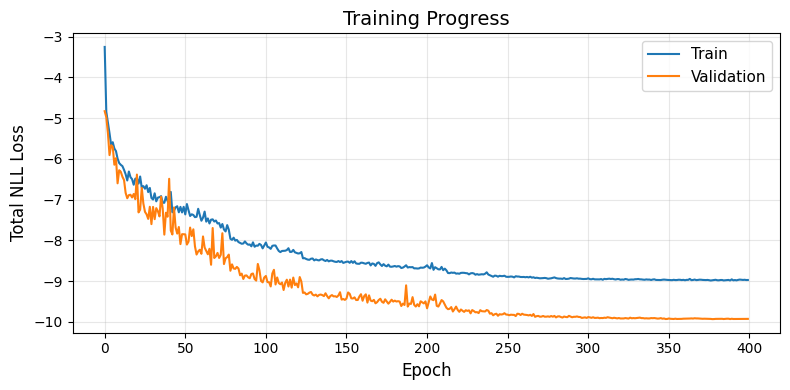

In [8]:
# Plot training and validation loss over epochs.
#
# The loss is Gaussian NLL, which can be negative — more negative means the
# network is fitting the data well AND reporting appropriately small uncertainty.
# Log scale doesn't work for negative values, so we use a linear y-axis here.
#
# What healthy training looks like:
#   - Both curves decrease (become more negative) and then level off
#   - The two curves stay close together → the model is generalizing well
#
# Signs of problems:
#   - Val loss diverges upward from train loss → overfitting
#   - Both curves plateau early → underfitting or bad hyperparams
#   - Loss spikes upward suddenly → learning rate too large or a bad batch

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(history['train'], label='Train', linewidth=1.5)
ax.plot(history['val'],   label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Total NLL Loss', fontsize=12)
ax.set_title('Training Progress', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evaluate on Test Set

In [14]:
# Reload the best checkpoint (lowest validation loss seen during training).
# map_location=device ensures the checkpoint loads correctly even if it was
# saved on a different device (e.g., loaded on CPU after training on GPU).
# weights_only=True is a security flag — only load weight tensors, not arbitrary
# Python objects, which prevents malicious checkpoint files from executing code.
model.load_state_dict(torch.load('checkpoints/best_model_notebook.pt',
                                  map_location=device, weights_only=True))
model.eval()

all_profiles_pred = []
all_profiles_true = []
all_tau_pred      = []
all_tau_true      = []
all_tau_std       = []
all_profiles_std  = []

with torch.no_grad():
    for x, prof_true, tau_true in test_loader:
        output = model(x.to(device))

        # output['profile'] is ALREADY in physical units (μm).
        # The network's forward method scales the sigmoid output:
        #   profile = sigmoid_output * (re_max - re_min) + re_min
        # So we do NOT need to denormalize this.
        prof_pred = output['profile'].cpu().numpy()

        # prof_true from the DataLoader IS normalized to [0, 1].
        # We denormalize it to μm using the same bounds the network uses,
        # so that predicted and true profiles are in the same units for comparison.
        prof_true_phys = (prof_true.numpy() * (config.re_max - config.re_min)
                          + config.re_min)

        # tau_c and tau_std are already in physical units (same scaling as profile)
        tau_pred_phys = output['tau_c'].squeeze(-1).cpu().numpy()
        tau_std_phys  = output['tau_std'].squeeze(-1).cpu().numpy()
        tau_true_phys = (tau_true.numpy() * (config.tau_max - config.tau_min)
                         + config.tau_min)

        prof_std = output['profile_std'].cpu().numpy()

        all_profiles_pred.append(prof_pred)
        all_profiles_true.append(prof_true_phys)
        all_profiles_std.append(prof_std)
        all_tau_pred.append(tau_pred_phys)
        all_tau_true.append(tau_true_phys)
        all_tau_std.append(tau_std_phys)

# np.concatenate joins all the batch arrays into one array over all test samples
profiles_pred = np.concatenate(all_profiles_pred)   # (n_test, n_levels)
profiles_true = np.concatenate(all_profiles_true)
tau_pred      = np.concatenate(all_tau_pred)         # (n_test,)
tau_true      = np.concatenate(all_tau_true)
tau_std       = np.concatenate(all_tau_std)          # (n_test,) — 1-sigma uncertainty on tau
profiles_std  = np.concatenate(all_profiles_std)  # (n_test, n_levels) — 1-sigma per level

print(f"Test samples: {len(profiles_pred)}")
# RMSE (root mean squared error) is in μm for profiles, dimensionless for tau.
# Lower is better. Compare against the natural variability of the quantity
# (e.g., if r_e varies over ~10 μm and RMSE=1 μm, that's a good retrieval).
print(f"Profile RMSE:  {np.sqrt(np.mean((profiles_pred - profiles_true)**2)):.3f} μm")
print(f"Tau RMSE:      {np.sqrt(np.mean((tau_pred - tau_true)**2)):.3f}")
print(f"Tau σ  — mean: {tau_std.mean():.3f},  median: {np.median(tau_std):.3f},  max: {tau_std.max():.3f}")

Test samples: 2395
Profile RMSE:  2.177 μm
Tau RMSE:      0.121
Tau σ  — mean: 0.262,  median: 0.212,  max: 0.940


In [ ]:
tau_true
tau_std

array([ 2.9158633, 37.448544 ,  1.6575633, ...,  2.902266 ,  9.47659  ,
       18.325375 ], dtype=float32)

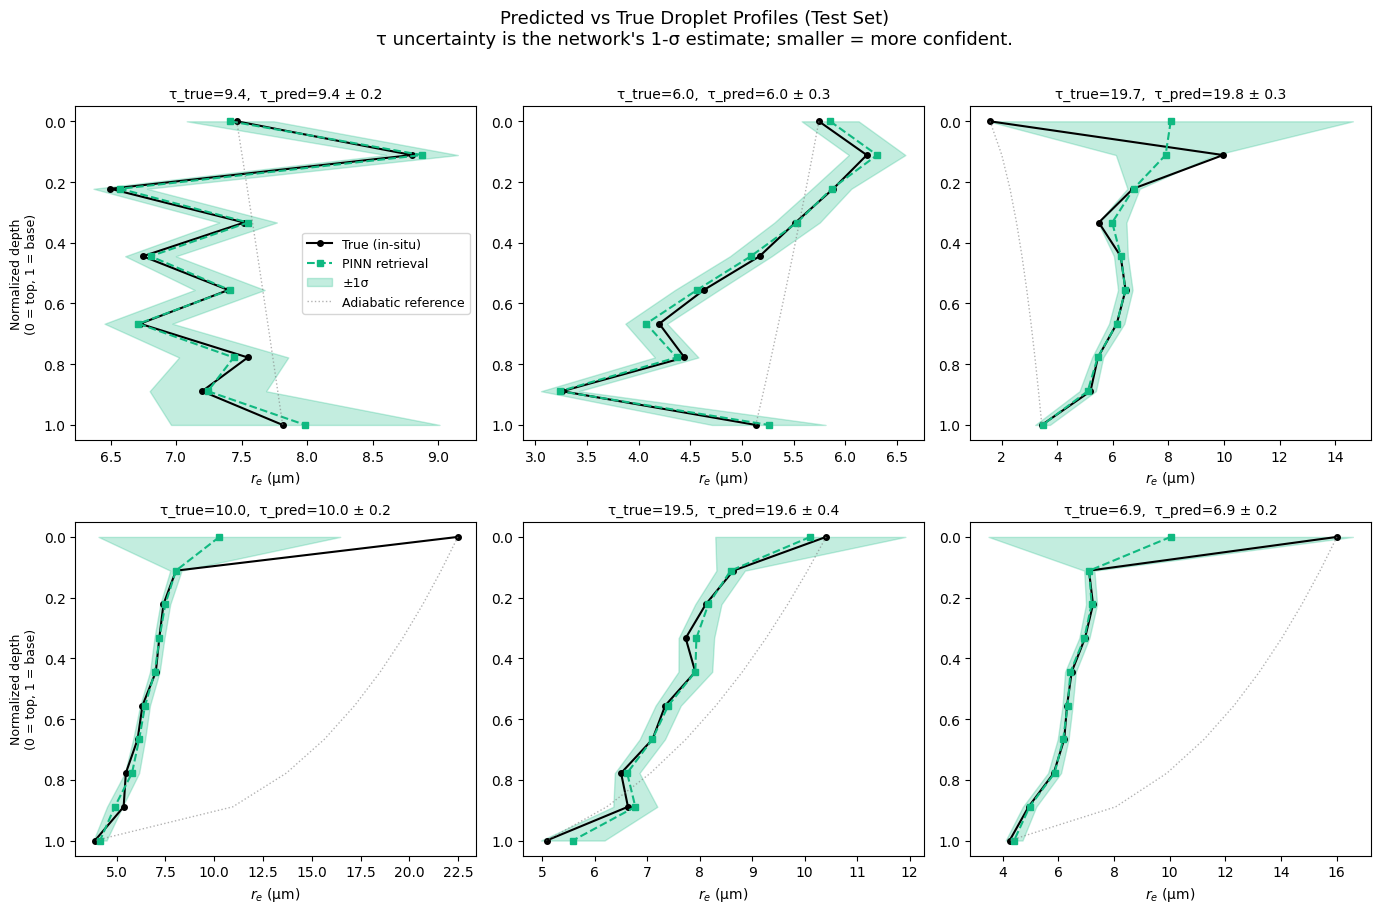

In [15]:
n_show = 6
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# z_norm: normalized vertical coordinate used as the y-axis.
# 0 = cloud top (index 0 in the profile arrays), 1 = cloud base (index -1).
# We use a normalized coordinate here because the 10 levels are evenly spaced
# within each cloud's geometric thickness, not at fixed altitudes.
z_norm = np.linspace(0, 1, config.n_levels)

# Pick random test cases for display. Fix the seed so the plot is reproducible.
rng_plot = np.random.default_rng(0)
idx = rng_plot.choice(len(profiles_pred), size=n_show, replace=False)

for k, (ax, i) in enumerate(zip(axes.flat, idx)):
    # True profile: the in-situ r_e measurement interpolated to 10 levels.
    # This is the ground truth — what we're asking the network to recover.
    ax.plot(profiles_true[i], z_norm, 'ko-', markersize=4, linewidth=1.5,
            label='True (in-situ)')

    # Predicted profile: the network's mean r_e estimate at the same 10 levels.
    ax.plot(profiles_pred[i], z_norm, 's--', color='#10B981', markersize=4,
            linewidth=1.5, label='PINN retrieval')

    # ±1σ uncertainty shading around the predicted profile.
    # profiles_std[i] is the per-level aleatoric uncertainty (μm) from the
    # network's profile_std_head. The shaded band spans mean ± 1σ at each level.
    ax.fill_betweenx(z_norm,
                     profiles_pred[i] - profiles_std[i],
                     profiles_pred[i] + profiles_std[i],
                     alpha=0.25, color='#10B981', label='±1σ')

    # Adiabatic reference: the smooth, monotonically increasing r_e profile
    # from Paper 1 Eq. 4, using the TRUE cloud top and base radii as endpoints.
    # This shows what the old Gauss-Newton method assumed — we're trying to do
    # better by not constraining the shape.
    r_adiab = adiabatic_profile(profiles_true[i, 0], profiles_true[i, -1], config.n_levels)
    ax.plot(r_adiab, z_norm, ':', color='gray', linewidth=1, alpha=0.6,
            label='Adiabatic reference')

    ax.set_xlabel('$r_e$ (μm)', fontsize=10)
    if k % 3 == 0:
        ax.set_ylabel('Normalized depth\n(0 = top, 1 = base)', fontsize=9)

    # invert_yaxis() puts cloud top (z_norm=0) at the top of the y-axis,
    # which is the conventional orientation for vertical atmospheric profiles.
    ax.invert_yaxis()

    # Show tau prediction with ±1σ uncertainty in the subplot title.
    # tau_std[i] is the network's estimated 1-sigma uncertainty on tau_c,
    # in the same physical units as tau_c.
    ax.set_title(
        f'τ_true={tau_true[i]:.1f},  '
        f'τ_pred={tau_pred[i]:.1f} ± {tau_std[i]:.1f}',
        fontsize=10,
    )
    if k == 0:
        ax.legend(fontsize=9)

plt.suptitle('Predicted vs True Droplet Profiles (Test Set)\n'
             'τ uncertainty is the network\'s 1-σ estimate; smaller = more confident.',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Load Checkpoint from Alpine

After running `train.py` on Alpine via SLURM, download the checkpoint
and load it here for analysis.

In [12]:
# ── Loading a checkpoint from an Alpine SLURM run ─────────────────────────────
#
# After train.py finishes on Alpine:
#   1. scp or rsync the checkpoint file to your local machine
#   2. Uncomment and update CHECKPOINT_PATH below
#
# The checkpoint saved by train.py is a dict with these keys:
#   'epoch'           — epoch number when this checkpoint was saved
#   'model_state_dict'— all network weights (same as model.state_dict())
#   'model_config'    — the RetrievalConfig kwargs, so you can rebuild the exact
#                       architecture without having to remember what was used
#   'val_loss'        — validation loss at that epoch (lower is better)
#   'optimizer_state_dict' — optimizer momentum buffers, so training can be
#                            resumed from exactly where it left off
#
# weights_only=False is needed when the checkpoint contains non-tensor objects
# (like the config dict). Only use this for checkpoints you generated yourself.

# CHECKPOINT_PATH = 'checkpoints/20260315_143022/best_model.pt'
#
# ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
#
# # Recreate the exact architecture that was used during that training run
# saved_config = RetrievalConfig(**ckpt['model_config'])
# model_alpine = DropletProfileNetwork(saved_config).to(device)
# model_alpine.load_state_dict(ckpt['model_state_dict'])
# model_alpine.eval()   # always call eval() before inference
#
# print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
# print(f"Validation loss at save: {ckpt['val_loss']:.6f}")
# print(f"Architecture: {saved_config}")